**Data to CSV**

In [17]:
# from scipy.io import loadmat
# import os
# import pandas as pd

# def load_data(mat_path, battery):
#     mat = loadmat(mat_path)
#     counter = 0
#     dataset = []

#     for i in range(len(mat[battery][0, 0]['cycle'][0])):
#         row = mat[battery][0, 0]['cycle'][0, i]
#         if row['type'][0] == 'discharge':
#             ambient_temperature = row['ambient_temperature'][0][0]
#             data = row['data']
#             capacity = data[0][0]['Capacity'][0][0]
#             for j in range(len(data[0][0]['Voltage_measured'][0])):
#                 voltage_measured = data[0][0]['Voltage_measured'][0][j]
#                 current_measured = data[0][0]['Current_measured'][0][j]
#                 temperature_measured = data[0][0]['Temperature_measured'][0][j]
#                 current_load = data[0][0]['Current_load'][0][j]
#                 voltage_load = data[0][0]['Voltage_load'][0][j]
#                 time = data[0][0]['Time'][0][j]
#                 dataset.append([counter + 1, ambient_temperature, capacity,
#                                 voltage_measured, current_measured,
#                                 temperature_measured, current_load,
#                                 voltage_load, time])
#             counter = counter + 1

#     return pd.DataFrame(data=dataset,
#                        columns=['cycle', 'ambient_temperature',
#                                 'capacity', 'voltage_measured',
#                                 'current_measured', 'temperature_measured',
#                                 'current_load', 'voltage_load', 'time'])

# def calculate_RUL(df):
#     eol_cycle = df['cycle'].max()

#     df['RUL'] = eol_cycle - df['cycle']

#     return df

# datasets = ["B0005", "B0006", "B0007", "B0018"]
# for name in datasets:
#     dataset = load_data(f'{name}.mat', name)
#     dataset_with_rul = calculate_RUL(dataset)

#     csv_filename = f'{name}_discharge.csv'
#     dataset_with_rul.to_csv(csv_filename, index=False)

**Import Libaraies**

In [18]:
import datetime
import numpy as np
import pandas as pd
from scipy.io import loadmat
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn import metrics
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Conv1D,
    BatchNormalization,
    Activation,
    Add,
    SpatialDropout1D,
    GlobalAveragePooling1D,
    Dropout,
    Dense,
)
from sklearn.metrics import mean_squared_error, mean_absolute_error
import random as rnd


In [19]:
# Change this to "LSTM" or "TCN" to select the model family for training.
MODEL_ARCHITECTURE = "TCN"

def build_lstm_model(input_shape, lstm_units=100, dense_units=50, dropout_rate=0.3):
    inputs = Input(shape=input_shape)
    x = LSTM(lstm_units, return_sequences=True)(inputs)
    x = Dropout(dropout_rate)(x)
    x = LSTM(lstm_units, return_sequences=True)(x)
    x = Dropout(dropout_rate)(x)
    x = LSTM(lstm_units)(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(dense_units, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(1, activation='linear')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def residual_tcn_block(x, filters, kernel_size, dilation_rate, dropout_rate):
    residual = x
    x = Conv1D(
        filters,
        kernel_size,
        padding='causal',
        dilation_rate=dilation_rate,
        kernel_initializer='he_normal',
    )(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(dropout_rate)(x)
    x = Conv1D(
        filters,
        kernel_size,
        padding='causal',
        dilation_rate=dilation_rate,
        kernel_initializer='he_normal',
    )(x)
    x = BatchNormalization()(x)

    if residual.shape[-1] != filters:
        residual = Conv1D(filters, 1, padding='same', kernel_initializer='he_normal')(residual)

    x = Add()([x, residual])
    return Activation('relu')(x)

def build_tcn_model(
    input_shape,
    filters=100,
    kernel_size=3,
    dropout_rate=0.2,
    dense_units=50,
    dilation_rates=(1, 2, 4),
    head_dropout_rate=0.0,
):
    inputs = Input(shape=input_shape)
    x = inputs
    for dilation_rate in dilation_rates:
        x = residual_tcn_block(x, filters, kernel_size, dilation_rate, dropout_rate)
    x = GlobalAveragePooling1D()(x)
    if head_dropout_rate:
        x = Dropout(head_dropout_rate)(x)
    x = Dense(dense_units, activation='relu')(x)
    if head_dropout_rate:
        x = Dropout(head_dropout_rate)(x)
    outputs = Dense(1, activation='linear')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def build_model(architecture, input_shape, **kwargs):
    architecture = architecture.upper()
    if architecture == 'LSTM':
        return build_lstm_model(input_shape, **kwargs)
    if architecture == 'TCN':
        return build_tcn_model(input_shape, **kwargs)
    raise ValueError(f"Unsupported architecture: {architecture}")


# Data Preprocessing


Data preprocessing to divide the data into sequences of 10 observations in each cycle, the sequence have overlap with eachother.

In [20]:
def generate_sequences(data, window_size):
    X, y_capacity, y_RUL, y_SOH = [], [], [], []
    cyclic_RUL_x, cyclic_RUL_y = [], []

    cycles = data['cycle'].unique()
    initial_capacity = data.iloc[0]['capacity']

    # Normalize all 'capacity' values by the first row's 'capacity' value
    data['SOH'] = data['capacity'] / initial_capacity

    # dividing the data of each cycle into sequences
    for cycle in cycles:
        cycle_data = data[data['cycle'] == cycle]
        cycle_observations = []
        num_rows = len(cycle_data)

        if num_rows >= window_size:
            for start in range(num_rows - window_size + 1):
                end = start + window_size

                features = cycle_data.iloc[start:end].drop(['cycle', 'capacity', 'RUL', 'SOH'], axis=1).values # Exclude 'cycle', 'capacity', 'RUL', 'SOH'
                target_capacity = cycle_data.iloc[end-1, cycle_data.columns.get_loc('capacity')] # Capacity target
                target_SOH = cycle_data.iloc[end-1, cycle_data.columns.get_loc('SOH')] # SOH target
                target_RUL = cycle_data.iloc[end-1, cycle_data.columns.get_loc('RUL')] # RUL target
                cycle_observations.append(features)
                X.append(features)
                y_capacity.append(target_capacity)
                y_SOH.append(target_SOH)
                y_RUL.append(target_RUL)

            cyclic_RUL_x.append(y_capacity[-1])
            cyclic_RUL_y.append(y_RUL[-1])

    return np.array(X), np.array(y_capacity), np.array(y_SOH), np.array(y_RUL), np.array(cyclic_RUL_x), np.array(cyclic_RUL_y)

In [21]:
file_path_0005 = "/content/drive/MyDrive/TProject/csv/B0005_discharge.csv"
file_path_0006 = "/content/drive/MyDrive/TProject/csv/B0006_discharge.csv"
file_path_0007 = "/content/drive/MyDrive/TProject/csv/B0007_discharge.csv"
file_path_0018 = "/content/drive/MyDrive/TProject/csv/B0018_discharge.csv"

# reading the data files
data_0005 = pd.read_csv(file_path_0005)
data_0006 = pd.read_csv(file_path_0006)
data_0007 = pd.read_csv(file_path_0007)
data_0018 = pd.read_csv(file_path_0018)

# making the sequnces for each data file
X_0005, y_capacit_0005, y_SOH_0005, y_RUL_0005, cyclic_RUL_x_0005, cyclic_RUL_y_0005 = generate_sequences(data_0005, 10)
X_0006, y_capacit_0006, y_SOH_0006,  y_RUL_0006, cyclic_RUL_x_0006, cyclic_RUL_y_0006 = generate_sequences(data_0006, 10)
X_0007, y_capacit_0007, y_SOH_0007,  y_RUL_0007, cyclic_RUL_x_0007, cyclic_RUL_y_0007 = generate_sequences(data_0007, 10)
X_0018, y_capacit_0018, y_SOH_0018,  y_RUL_0018, cyclic_RUL_x_0018, cyclic_RUL_y_0018 = generate_sequences(data_0018, 10)

In [22]:
# concatenating the data
X = np.concatenate((X_0005, X_0006, X_0007, X_0018), axis=0)
y_capacity = np.concatenate((y_capacit_0005, y_capacit_0006, y_capacit_0007, y_capacit_0018), axis=0)
y_SOH = np.concatenate((y_SOH_0005, y_SOH_0006, y_SOH_0007, y_SOH_0018), axis=0)
y_RUL = np.concatenate((y_RUL_0005, y_RUL_0006, y_RUL_0007, y_RUL_0018), axis=0)
cyclic_RUL_x = np.concatenate((cyclic_RUL_x_0005, cyclic_RUL_x_0006, cyclic_RUL_x_0007, cyclic_RUL_x_0018), axis=0)
cyclic_RUL_y = np.concatenate((cyclic_RUL_y_0005, cyclic_RUL_y_0006, cyclic_RUL_y_0007, cyclic_RUL_y_0018), axis=0)

# Predicting SOH/Capacity

## predicting raw capacity

This step is only added for the sake of comparing our method with baselines since they predict raw capacity rather than SOH, and this model is not part of our pipeline

In [23]:
# data split into train, test, validation
X_capacity_train, X_capacity_testval, y_capacity_train, y_capacity_testval = train_test_split(
    X, y_capacity, test_size=0.2, random_state=42
)

X_capacity_test, X_capacity_validation, y_capacity_test, y_capacity_validation = train_test_split(
    X_capacity_testval, y_capacity_testval, test_size=0.5, random_state=42
)

In [24]:
# architecture of model
time_steps = X_capacity_train.shape[1]
features = X_capacity_train.shape[2]

if MODEL_ARCHITECTURE == "LSTM":
    model = build_model(
        MODEL_ARCHITECTURE,
        (time_steps, features),
        lstm_units=100,
        dropout_rate=0.2,
        dense_units=50,
    )
else:  # TCN
    model = build_model(
        MODEL_ARCHITECTURE,
        (time_steps, features),
        filters=100,
        kernel_size=3,
        dropout_rate=0.2,
        dense_units=50,
        dilation_rates=(1, 2, 4),
        head_dropout_rate=0.0,
    )


In [25]:
# training and saving the model
history = model.fit(X_capacity_train, y_capacity_train, epochs=20, validation_data=(X_capacity_validation, y_capacity_validation), verbose=1)
model.save(f'/content/drive/MyDrive/TProject/models/Raw_Capacity_{MODEL_ARCHITECTURE}.h5')


Epoch 1/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 124s 26ms/step - loss: 64.5208 - val_loss: 0.4486
Epoch 2/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 119s 26ms/step - loss: 30.9784 - val_loss: 4.4328
Epoch 3/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 139s 26ms/step - loss: 16.2417 - val_loss: 0.5602
Epoch 4/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 118s 26ms/step - loss: 12.0278 - val_loss: 5.5645
Epoch 5/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 119s 26ms/step - loss: 9.2511 - val_loss: 36.2373
Epoch 6/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 142s 26ms/step - loss: 4.9909 - val_loss: 3.2113
Epoch 7/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 146s 27ms/step - loss: 4.9654 - val_loss: 0.0613
Epoch 8/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 121s 27ms/step - loss: 4.5317 - val_loss: 0.0412
Epoch 9/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 119s 27ms/step - loss: 2.6536 - val_loss: 0.1014
Epoch 10/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 139s 26ms/step - loss: 1.4902 - val_loss: 0.1574
Epoch 11/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 115s 26ms/step - loss: 1.3374 - val_loss:

### testing

In [26]:
# loading the model
cap_model = load_model(f'/content/drive/MyDrive/TProject/models/Raw_Capacity_{MODEL_ARCHITECTURE}.h5')
cap_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 10, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 10, 100)   │      2,200 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 100)   │        400 │ conv1d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 10, 100)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_3 │ (None, 10, 100)   │          0 │ activation_6[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 10, 100)   │     30,100 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 100)   │        400 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 10, 100)   │        800 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 10, 100)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 10, 100)   │          0 │ add_3[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 10, 100)   │     30,100 │ activation_7[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 100)   │        400 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 10, 100)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_4 │ (None, 10, 100)   │          0 │ activation_8[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 10, 100)   │     30,100 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 100)   │        400 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 10, 100)   │          0 │ batch_normalizat… │
│                     │                   │            │ activation_7[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 10, 100)   │          0 │ add_4[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 161,003 (628.92 KB)

 Trainable params: 159,801 (624.22 KB)

 Non-trainable params: 1,200 (4.69 KB)

 Optimizer params: 2 (12.00 B)

563/563 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step
Mean Squared Error: 0.02397379854654629
Mean Absolute Error: 0.12976239661222153
Root Mean Squared Error: 0.15483474592786428


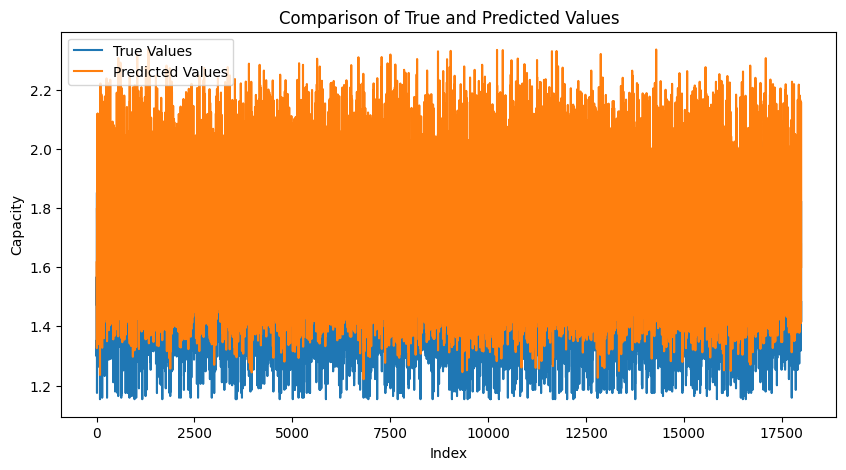

In [27]:
# testing the accuracy of model on test dataset
predicted_y = cap_model.predict(X_capacity_test)
true_y = y_capacity_test

mse = mean_squared_error(true_y, predicted_y)
mae = mean_absolute_error(true_y, predicted_y)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

plt.figure(figsize=(10, 5))

plt.plot(true_y, label='True Values')

plt.plot(predicted_y, label='Predicted Values')

plt.title('Comparison of True and Predicted Values')
plt.xlabel('Index')
plt.ylabel('Capacity')
plt.legend()
plt.show()

## predicting SOH (main method)

This is for predicting the SOH (currecnt capacity / initial capacity) which is used as input for the RUL model.

In [28]:
# spliting data into train, test, validation
X_SOH_train, X_SOH_testval, y_SOH_train, y_SOH_testval = train_test_split(
    X, y_SOH, test_size=0.2, random_state=42
)

X_SOH_test, X_SOH_validation, y_SOH_test, y_SOH_validation = train_test_split(
    X_SOH_testval, y_SOH_testval, test_size=0.5, random_state=42
)

In [30]:
# architecture of the model
time_steps = X_SOH_train.shape[1]
features = X_SOH_train.shape[2]

if MODEL_ARCHITECTURE == "LSTM":
    model = build_model(
        MODEL_ARCHITECTURE,
        (time_steps, features),
        lstm_units=100,
        dropout_rate=0.2,
        dense_units=50,
    )
else:  # TCN
    model = build_model(
        MODEL_ARCHITECTURE,
        (time_steps, features),
        filters=100,
        kernel_size=3,
        dropout_rate=0.2,
        dense_units=50,
        dilation_rates=(1, 2, 4),
        head_dropout_rate=0.0,
    )



In [31]:
# training the model
history = model.fit(X_SOH_train, y_SOH_train, epochs=20, validation_data=(X_SOH_validation, y_SOH_validation), verbose=1)
model.save(f'/content/drive/MyDrive/TProject/models/SOH_{MODEL_ARCHITECTURE}.h5')


Epoch 1/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 132s 28ms/step - loss: 153.6711 - val_loss: 8.9148
Epoch 2/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 117s 26ms/step - loss: 26.1321 - val_loss: 2.1010
Epoch 3/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 117s 26ms/step - loss: 19.8808 - val_loss: 0.4844
Epoch 4/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 118s 26ms/step - loss: 11.0852 - val_loss: 0.8038
Epoch 5/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 115s 26ms/step - loss: 10.6583 - val_loss: 0.2076
Epoch 6/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 117s 26ms/step - loss: 8.9251 - val_loss: 0.2822
Epoch 7/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 118s 26ms/step - loss: 8.9965 - val_loss: 0.0368
Epoch 8/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 118s 26ms/step - loss: 6.8091 - val_loss: 1.9496
Epoch 9/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 116s 26ms/step - loss: 4.0158 - val_loss: 5.5488
Epoch 10/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 117s 26ms/step - loss: 4.2929 - val_loss: 0.0043
Epoch 11/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 141s 26ms/step - loss: 2.8619 - val_loss

### Testing

In [32]:
# loading the model
SOH_model = load_model(f'/content/drive/MyDrive/TProject/models/SOH_{MODEL_ARCHITECTURE}.h5')
SOH_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 10, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 10, 100)   │      2,200 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 100)   │        400 │ conv1d_14[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 10, 100)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_6 │ (None, 10, 100)   │          0 │ activation_12[0]… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 10, 100)   │     30,100 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 100)   │        400 │ conv1d_15[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 10, 100)   │        800 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 10, 100)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 10, 100)   │          0 │ add_6[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 10, 100)   │     30,100 │ activation_13[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 100)   │        400 │ conv1d_17[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 10, 100)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_7 │ (None, 10, 100)   │          0 │ activation_14[0]… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 10, 100)   │     30,100 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 100)   │        400 │ conv1d_18[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 10, 100)   │          0 │ batch_normalizat… │
│                     │                   │            │ activation_13[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 10, 100)   │          0 │ add_7[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 161,003 (628.92 KB)

 Trainable params: 159,801 (624.22 KB)

 Non-trainable params: 1,200 (4.69 KB)

 Optimizer params: 2 (12.00 B)

563/563 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step
Mean Squared Error: 0.010924406995809965
Mean Absolute Error: 0.0897296959988847
Root Mean Squared Error: 0.10451988803959734


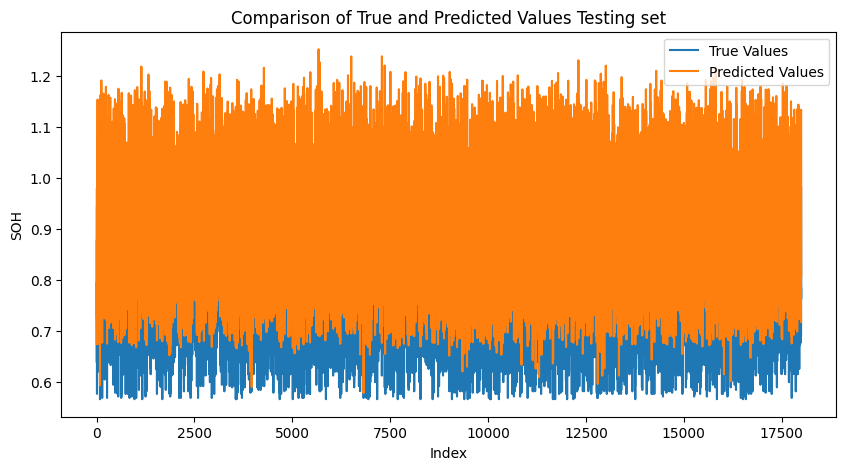

In [33]:
# testing the accuracy of model on thw test dataset
predicted_y = SOH_model.predict(X_SOH_test)
true_y = y_SOH_test

mse = mean_squared_error(true_y, predicted_y)
mae = mean_absolute_error(true_y, predicted_y)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

plt.figure(figsize=(10, 5))

plt.plot(true_y, label='True Values')

plt.plot(predicted_y, label='Predicted Values')

plt.title('Comparison of True and Predicted Values Testing set')
plt.xlabel('Index')
plt.ylabel('SOH')
plt.legend()
plt.show()

4500/4500 ━━━━━━━━━━━━━━━━━━━━ 35s 8ms/step
Mean Squared Error: 0.010881048064224949
Mean Absolute Error: 0.08939130378622104
Root Mean Squared Error: 0.1043122622908014


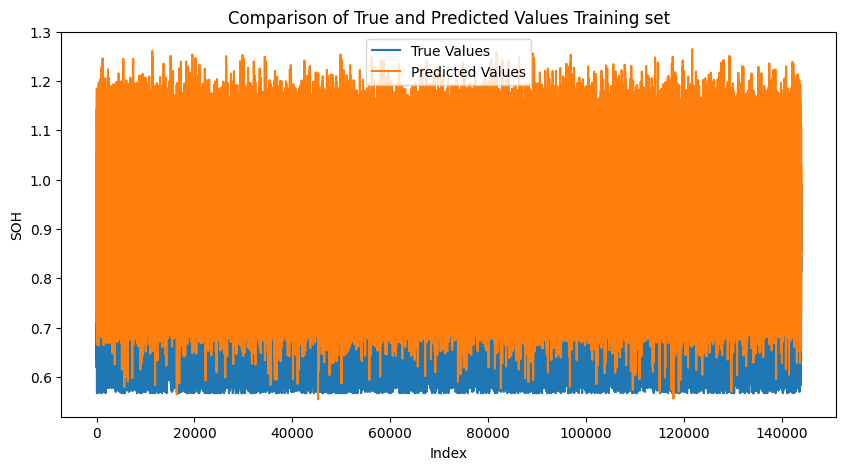

In [34]:
# testing the accuracy of model on train dataset
predicted_y = SOH_model.predict(X_SOH_train)
true_y = y_SOH_train

mse = mean_squared_error(true_y, predicted_y)
mae = mean_absolute_error(true_y, predicted_y)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

plt.figure(figsize=(10, 5))

plt.plot(true_y, label='True Values')

plt.plot(predicted_y, label='Predicted Values')

plt.title('Comparison of True and Predicted Values Training set')
plt.xlabel('Index')
plt.ylabel('SOH')
plt.legend()
plt.show()

# Predicting RUL

In [35]:
# reshaping the cyclic_RUL_x data so that each element is a numpy array
cyclic_RUL_x_reshaped = np.empty((cyclic_RUL_x.shape[0], 1))
for i in range(cyclic_RUL_x.shape[0]):
  cyclic_RUL_x_reshaped[i] = np.array([cyclic_RUL_x[i]])

In [36]:
# scaling the RUL values between 0 and 1
scaler = MinMaxScaler()
scaled_rul = scaler.fit_transform(cyclic_RUL_y.reshape(-1, 1))

In [37]:
# generating sequntial data for RUL prediction given SOH, here we use sequences of 3 cycles (not observation, note that the SOH and RUL are constant in each cycle)
def generate_sequences_RUL(capacity, RUL_GT, window_size):
  X, y_RUL = [], []
  for start in range(capacity.shape[0] - window_size + 1):
    end = start + window_size

    features = capacity[start:end]
    target_RUL = RUL_GT[end-1]
    X.append(features)
    y_RUL.append(target_RUL)

  return np.array(X), np.array(y_RUL)

In [38]:
X_for_RUL, y_RUL = generate_sequences_RUL(cyclic_RUL_x_reshaped, scaled_rul, 3)

In [39]:
# spliting the data into train, test, and validation
X_RUL_train, X_RUL_testval, y_RUL_train, y_RUL_testval = train_test_split(
    X_for_RUL, y_RUL, test_size=0.1, random_state=42
)

X_RUL_test, X_RUL_validation, y_RUL_test, y_RUL_validation = train_test_split(
    X_RUL_testval, y_RUL_testval, test_size=0.5, random_state=42
)

In [40]:
# architecture of the model
if MODEL_ARCHITECTURE == "LSTM":
    model = build_model(
        MODEL_ARCHITECTURE,
        (X_RUL_train.shape[1], 1),
        lstm_units=200,
        dropout_rate=0.3,
        dense_units=50,
    )
else:  # TCN
    model = build_model(
        MODEL_ARCHITECTURE,
        (X_RUL_train.shape[1], 1),
        filters=128,
        kernel_size=2,
        dropout_rate=0.3,
        dense_units=50,
        dilation_rates=(1, 2, 4),
        head_dropout_rate=0.3,
    )


In [41]:
# training and saving the model
history = model.fit(X_RUL_train, y_RUL_train, epochs=200, validation_data=(X_RUL_validation, y_RUL_validation), verbose=1)
model.save(f'/content/drive/MyDrive/TProject/models/RUL_{MODEL_ARCHITECTURE}.h5')


Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 3.5203 - val_loss: 1.8934
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.5178 - val_loss: 1.3116
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.8488 - val_loss: 0.0776
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5590 - val_loss: 0.0434
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3191 - val_loss: 0.0391
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2546 - val_loss: 0.0328
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2152 - val_loss: 0.0275
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1644 - val_loss: 0.0257
Epoch 9/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1206 - val_loss: 0.0239
Epoch 10/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1312 - val_loss: 0.0182
Epoch 11/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.1036 - val_loss: 0.0169
Epoch 12/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step

### testing

In [42]:
# loading the model
RUL_model = load_model(f'/content/drive/MyDrive/TProject/models/RUL_{MODEL_ARCHITECTURE}.h5')
RUL_model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 3, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 3, 128)    │        384 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 128)    │        512 │ conv1d_21[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 3, 128)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_9 │ (None, 3, 128)    │          0 │ activation_18[0]… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 3, 128)    │     32,896 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 128)    │        512 │ conv1d_22[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 3, 128)    │        256 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 3, 128)    │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_23[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 3, 128)    │          0 │ add_9[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 3, 128)    │     32,896 │ activation_19[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 128)    │        512 │ conv1d_24[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 3, 128)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_… │ (None, 3, 128)    │          0 │ activation_20[0]… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_25 (Conv1D)  │ (None, 3, 128)    │     32,896 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 128)    │        512 │ conv1d_25[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 3, 128)    │          0 │ batch_normalizat… │
│                     │                   │            │ activation_19[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 3, 128)    │          0 │ add_10[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 174,695 (682.41 KB)

 Trainable params: 173,157 (676.39 KB)

 Non-trainable params: 1,536 (6.00 KB)

 Optimizer params: 2 (12.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
Mean Squared Error: 0.02158117353589486
Mean Absolute Error: 0.12170879204595787
Root Mean Squared Error: 0.14690532167316084


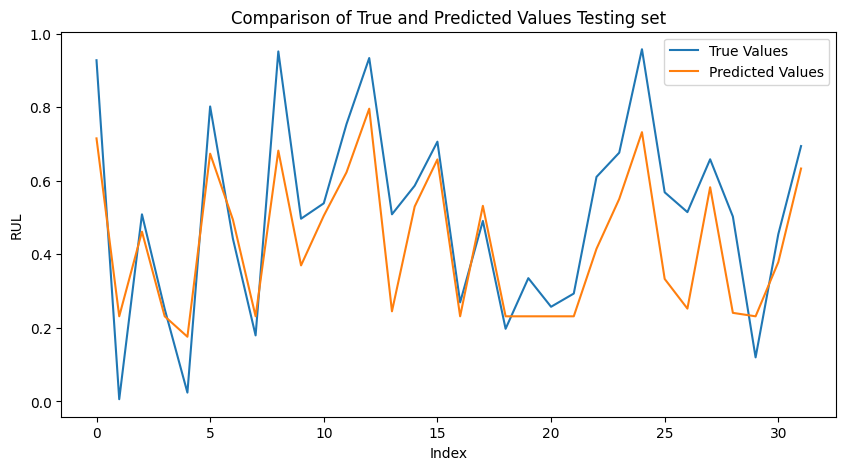

In [43]:
# testing the model on test dataset
predicted_y = RUL_model.predict(X_RUL_test)
true_y = y_RUL_test

mse = mean_squared_error(true_y, predicted_y)
mae = mean_absolute_error(true_y, predicted_y)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

plt.figure(figsize=(10, 5))

plt.plot(true_y, label='True Values')

plt.plot(predicted_y, label='Predicted Values')

plt.title('Comparison of True and Predicted Values Testing set')
plt.xlabel('Index')
plt.ylabel('RUL')
plt.legend()
plt.show()

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Mean Squared Error: 0.015807673632890092
Mean Absolute Error: 0.10640398535358142
Root Mean Squared Error: 0.12572857126719483


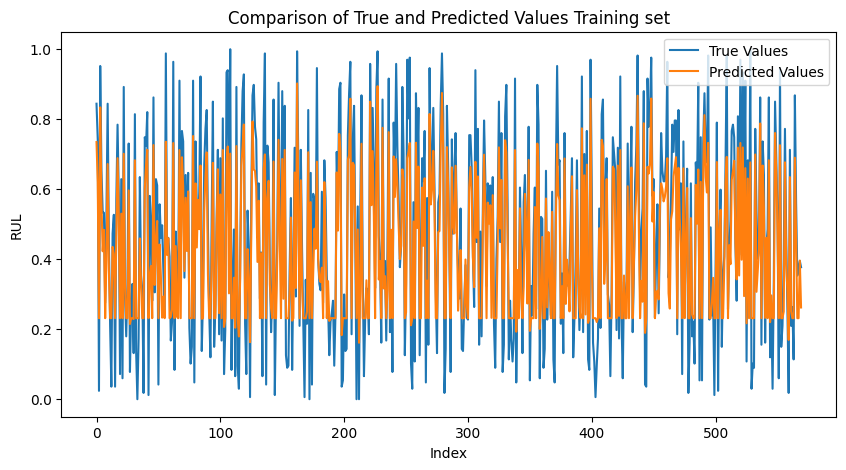

In [44]:
# testing the model on train dataset
predicted_y = RUL_model.predict(X_RUL_train)
true_y = y_RUL_train

mse = mean_squared_error(true_y, predicted_y)
mae = mean_absolute_error(true_y, predicted_y)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

plt.figure(figsize=(10, 5))

plt.plot(true_y, label='True Values')

plt.plot(predicted_y, label='Predicted Values')

plt.title('Comparison of True and Predicted Values Training set')
plt.xlabel('Index')
plt.ylabel('RUL')
plt.legend()
plt.show()